In [1]:
# ══════════════════════════════════════════════════════════════════
# NB03 — Publisher & Platform Analysis
# The Platform Shift: A Deep Dive
# ══════════════════════════════════════════════════════════════════
#
# Objective:
#   Analyse the PC platform strategy of each target Japanese publisher
#   using Steam data (NB01) and IR revenue data (NB02).
#   Central question: does PC port cadence and reception correlate
#   with revenue trajectory?
#
# Inputs:
#   ../data/raw/details/*.json
#   ../data/raw/reviews/*.json
#   ../data/processed/NB02_revenue_data.csv
#   ../data/processed/NB02_revenue_pivot.csv
#
# Outputs:
#   ../data/processed/NB03_port_timeline.csv
#   ../data/processed/NB03_publisher_metrics.csv
#   ../data/processed/NB03_platform_chart.png
#   ../data/processed/NB03_cadence_revenue_chart.png
#
# Notebook map:
#   Cell 1  — Config & imports
#   Cell 2  — Load NB01 + NB02 outputs
#   Cell 3  — PC port timeline per publisher
#   Cell 4  — Port cadence metrics
#   Cell 5  — Review volume as PC audience proxy
#   Cell 6  — Publisher metrics table (cross-tab)
#   Cell 7  — Thesis finding: OLS R² on cadence vs revenue
#   Cell 8  — Visualization: port timeline heatmap
#   Cell 9  — Visualization: cadence vs revenue scatter
#   Cell 10 — Save outputs
#   Cell 11 — NB03 Observation
# ══════════════════════════════════════════════════════════════════

# ── CELL 1: Config & imports ──────────────────────────────────────
USE_CACHE = True

import sys
import warnings
import importlib
import json
from pathlib import Path
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('../').resolve()
PROCESSED    = PROJECT_ROOT / 'data' / 'processed'
sys.path.insert(0, str(PROJECT_ROOT / 'extractors'))

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# JP font
for font in ['MS Gothic', 'Yu Gothic', 'Meiryo', 'IPAGothic']:
    try:
        matplotlib.font_manager.findfont(font, fallback_to_default=False)
        matplotlib.rcParams['font.family'] = font
        break
    except Exception:
        continue

plt.rcParams.update({
    'font.family':      'Segoe UI',
    'font.size':        10,
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#252836',
    'axes.edgecolor':   '#2D3148',
    'axes.labelcolor':  '#CCCCCC',
    'xtick.color':      '#CCCCCC',
    'ytick.color':      '#CCCCCC',
    'text.color':       '#FFFFFF',
    'grid.color':       '#2D3148',
    'legend.facecolor': '#1F2937',
    'legend.edgecolor': '#374151',
})

PUBLISHER_COLORS = {
    'sie':          '#E8780A',
    'bandai_namco': '#C8A800',
    'sega_atlus':   '#4A90D9',
    'square_enix':  '#E4002B',
    'nintendo':     '#E4000F',
    'ea':           '#D63800',
    'take_two':     '#2B5BB5',
    'ubisoft':      '#6B7A8D',
}

DISPLAY_NAMES = {
    'sie':          'SIE',
    'bandai_namco': 'Bandai Namco',
    'sega_atlus':   'Sega/Atlus',
    'square_enix':  'Square Enix',
    'nintendo':     'Nintendo',
    'ea':           'EA',
    'take_two':     'Take-Two',
    'ubisoft':      'Ubisoft',
}

JP_TARGETS   = ['sie', 'bandai_namco', 'sega_atlus', 'square_enix']
JP_BENCHMARK = ['nintendo']
WESTERN      = ['ea', 'take_two', 'ubisoft']
ALL_GROUPS   = JP_TARGETS + JP_BENCHMARK + WESTERN

# Single source of truth for the NB02→NB01 key mapping.
# NB01 uses 'sie' / 'sega_atlus'; NB02 uses 'sony' / 'sega_sammy'.
# This dict lives here once and is imported by downstream notebooks.
NB02_TO_NB01 = {
    'sony':         'sie',
    'bandai_namco': 'bandai_namco',
    'sega_sammy':   'sega_atlus',
    'square_enix':  'square_enix',
    'nintendo':     'nintendo',
    'ea':           'ea',
    'take_two':     'take_two',
    'ubisoft':      'ubisoft',
}

ANALYSIS_WINDOW = (2018, 2025)  # Steam release years to consider

print('NB03 config loaded')
print(f'PROCESSED : {PROCESSED}')
print(f'JP targets: {JP_TARGETS}')
print(f'Benchmarks: {JP_BENCHMARK + WESTERN}')


NB03 config loaded
PROCESSED : C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed
JP targets: ['sie', 'bandai_namco', 'sega_atlus', 'square_enix']
Benchmarks: ['nintendo', 'ea', 'take_two', 'ubisoft']


In [2]:
# ── CELL 2: Load NB01 + NB02 outputs ─────────────────────────────
import game_registry
importlib.reload(game_registry)
from game_registry import GAME_REGISTRY

# ── Rebuild registry_df from source ──────────────────────────────
rows = []
for publisher, games in GAME_REGISTRY.items():
    for title, meta in games.items():
        rows.append({
            'title':            title,
            'publisher_group':  publisher,
            'appid':            meta.get('appid'),
            'release_pc':       meta.get('release_pc'),
            'release_console':  meta.get('release_console'),
            'note':             meta.get('note', ''),
        })
registry_df = pd.DataFrame(rows)
registry_df['has_appid']    = registry_df['appid'].notna()
registry_df['appid']        = pd.to_numeric(registry_df['appid'], errors='coerce').astype('Int64')
registry_df['release_pc']   = pd.to_datetime(registry_df['release_pc'], errors='coerce')
registry_df['release_year'] = registry_df['release_pc'].dt.year.astype('Int64')
trackable = registry_df[registry_df['has_appid']].copy()

# ── App details from raw JSON ─────────────────────────────────────
RAW_DETAILS = PROJECT_ROOT / 'data' / 'raw' / 'details'
details_rows = []
for p in RAW_DETAILS.glob('*.json'):
    with open(p) as f:
        details_rows.append(json.load(f))
details_df = pd.DataFrame(details_rows)
details_df['appid'] = pd.to_numeric(details_df['appid'], errors='coerce').astype('Int64')

app_details = details_df.merge(
    trackable[['appid', 'publisher_group', 'release_pc', 'release_year', 'title']],
    on='appid', how='left'
).rename(columns={'release_pc': 'release_date'})

# ── Reviews summary from raw JSON ────────────────────────────────
RAW_REVIEWS = PROJECT_ROOT / 'data' / 'raw' / 'reviews'
review_rows = []
for p in RAW_REVIEWS.glob('*.json'):
    with open(p) as f:
        d = json.load(f)
    qs = d.get('query_summary') or {}
    review_rows.append({
        'appid':               d.get('appid'),
        'total_reviews':       int(d.get('total_collected') or 0),
        'total_positive':      int(qs.get('total_positive') or 0),
        'total_reviews_steam': int(qs.get('total_reviews')  or 0),
    })
reviews_all = pd.DataFrame(review_rows)
reviews_all['appid'] = pd.to_numeric(reviews_all['appid'], errors='coerce').astype('Int64')

denom = reviews_all['total_reviews_steam'].astype(float)
numer = reviews_all['total_positive'].astype(float)
reviews_all['review_score'] = np.where(denom > 0, (numer / denom * 10).round(2), np.nan)

reviews_all = reviews_all.merge(
    trackable[['appid', 'publisher_group', 'release_year']],
    on='appid', how='left'
)

# ── NB02 revenue ──────────────────────────────────────────────────
revenue_df = pd.read_csv(PROCESSED / 'NB02_revenue_data.csv')
pivot_raw  = pd.read_csv(PROCESSED / 'NB02_revenue_pivot.csv', index_col=0)
pivot_raw.columns = [int(c) if str(c).isdigit() else c for c in pivot_raw.columns]
revenue_df['publisher_group'] = revenue_df['company'].map(NB02_TO_NB01)

# Filter to analysis window
apps = app_details[
    app_details['release_year'].between(*ANALYSIS_WINDOW)
].copy()

print(f'registry_df : {len(registry_df)} titles | {registry_df["publisher_group"].nunique()} groups')
print(f'app_details : {len(app_details)} rows')
print(f'reviews_all : {len(reviews_all)} rows')
print(f'revenue_df  : {len(revenue_df)} rows')
print(f'apps (window {ANALYSIS_WINDOW[0]}–{ANALYSIS_WINDOW[1]}): {len(apps)} titles')
print()
print('Publisher groups:')
print(app_details['publisher_group'].value_counts().to_string())


registry_df : 48 titles | 8 groups
app_details : 47 rows
reviews_all : 46 rows
revenue_df  : 31 rows
apps (window 2018–2025): 43 titles

Publisher groups:
publisher_group
square_enix     11
sie             10
sega_atlus       8
bandai_namco     8
ea               3
take_two         3
ubisoft          3


In [3]:
# ── CELL 3: PC Port Timeline ──────────────────────────────────────
# Builds two outputs from the merged registry:
#
#   port_timeline_df  — title-level long-format DataFrame
#     Columns: appid, title, publisher_group, release_console,
#              release_pc, release_year, gap_days, gap_category,
#              oc_score (None — filled by prepare_streamlit_data.py),
#              positive_rate (None — filled by prepare_streamlit_data.py)
#
#   timeline_pivot    — wide publisher × year pivot (used by Cell 8
#                       heatmap and Cell 4 cadence metrics; unchanged)
#
# PC-native titles (no meaningful console→PC gap):
#   Final Fantasy XIV Online  — PC-native MMO; consoles followed later
#   Apex Legends              — PC-first; console release Nov 2019
#
# ⚠  FF7 Rebirth: release_pc in registry is 2024-01-23 (likely wrong;
#    patch file has 2025-01-23). Gap clamped to 0. Verify before
#    finalising Streamlit dashboard.

PC_NATIVE = {"Final Fantasy XIV Online", "Apex Legends"}

def gap_category(gap):
    if gap is None:    return "PC-native / PC-first"
    if gap == 0:       return "Day-and-date"
    if gap <= 30:      return "Near-simultaneous (\u226430d)"
    if gap <= 365:     return "Short wait (1\u201312m)"
    if gap <= 730:     return "Medium wait (1\u20132yr)"
    return                    "Long wait (>2yr)"

# ── Build title-level long format ────────────────────────────────
timeline_rows = []
for publisher, games in GAME_REGISTRY.items():
    for title, meta in games.items():
        appid = meta.get("appid")
        if not appid:
            continue                              # Nintendo — no Steam presence
        rpc  = meta.get("release_pc")
        rcon = meta.get("release_console")

        if title in PC_NATIVE:
            gap  = None
            gcat = gap_category(None)
        elif rpc and rcon:
            dpc  = pd.to_datetime(rpc)
            dcon = pd.to_datetime(rcon)
            gap  = max((dpc - dcon).days, 0)    # clamp negatives (data noise)
            gcat = gap_category(gap)
        else:
            gap  = None
            gcat = "Unknown"

        timeline_rows.append({
            "appid":           appid,
            "title":           title,
            "publisher_group": publisher,
            "release_console": rcon,
            "release_pc":      rpc,
            "gap_days":        gap,
            "gap_category":    gcat,
            "oc_score":        None,    # filled by prepare_streamlit_data.py
            "positive_rate":   None,    # filled by prepare_streamlit_data.py
        })

port_timeline_df = pd.DataFrame(timeline_rows)
port_timeline_df["release_pc"]      = pd.to_datetime(port_timeline_df["release_pc"])
port_timeline_df["release_console"] = pd.to_datetime(port_timeline_df["release_console"])
port_timeline_df["release_year"]    = port_timeline_df["release_pc"].dt.year.astype("Int64")

col_order = ["appid", "title", "publisher_group", "release_console",
             "release_pc", "release_year", "gap_days", "gap_category",
             "oc_score", "positive_rate"]
port_timeline_df = port_timeline_df[col_order]

# ── Derive timeline_pivot for downstream cells (unchanged) ───────
# Filter to analysis window for publisher-level cadence / heatmap
in_window = port_timeline_df[
    port_timeline_df["release_year"].between(
        ANALYSIS_WINDOW[0], ANALYSIS_WINDOW[1]
    )
].copy()

timeline = (
    in_window
    .groupby(["publisher_group", "release_year"])
    .size()
    .reset_index(name="titles_released")
)

timeline_pivot = timeline.pivot(
    index="publisher_group",
    columns="release_year",
    values="titles_released",
).fillna(0).astype(int)

for yr in range(ANALYSIS_WINDOW[0], ANALYSIS_WINDOW[1] + 1):
    if yr not in timeline_pivot.columns:
        timeline_pivot[yr] = 0
timeline_pivot = timeline_pivot[sorted(timeline_pivot.columns)]
timeline_pivot = timeline_pivot.reindex(
    [p for p in ALL_GROUPS if p in timeline_pivot.index]
)

# ── Print ─────────────────────────────────────────────────────────
print("Title-level port timeline (46 rows):")
print(port_timeline_df[["title", "publisher_group",
                          "gap_days", "gap_category"]].to_string(index=False))
print()
print("Gap category breakdown:")
print(port_timeline_df["gap_category"].value_counts().to_string())
print()
print("PC title release timeline (publisher × year):")
print(timeline_pivot.to_string())
print()
print("Total titles per publisher (analysis window):")
print(timeline_pivot.sum(axis=1).sort_values(ascending=False).to_string())


Title-level port timeline (46 rows):
                              title publisher_group gap_days         gap_category
                  God of War (2018)             sie     None              Unknown
                God of War Ragnarök             sie     None              Unknown
                  Horizon Zero Dawn             sie     None              Unknown
             Horizon Forbidden West             sie     None              Unknown
     Marvel's Spider-Man Remastered             sie     None              Unknown
 Marvel's Spider-Man: Miles Morales             sie     None              Unknown
              The Last of Us Part I             sie     None              Unknown
                       Helldivers 2             sie     None              Unknown
                           Returnal             sie     None              Unknown
        Ratchet & Clank: Rift Apart             sie     None              Unknown
                         Elden Ring    bandai_namco     None 

In [4]:
# ── CELL 4: Port Cadence Metrics ──────────────────────────────────
# Metrics per publisher:
#   total_titles      : total Steam titles in analysis window
#   titles_per_year   : average annual PC releases
#   active_years      : years with ≥1 release
#   peak_year         : year with most releases
#   peak_count        : titles in peak year
#   recent_3yr        : titles in FY2023-2025 (momentum indicator)
#   acceleration      : recent_3yr / total_titles (recency weight)
#
# Known gap: console→PC lag requires console release dates not
# available from Steam alone. Flagged for NB05 via IGDB/VGChartz.

years   = list(range(ANALYSIS_WINDOW[0], ANALYSIS_WINDOW[1] + 1))
n_years = len(years)
recent_window = [2023, 2024, 2025]

cadence_rows = []
for pub in ALL_GROUPS:
    if pub not in timeline_pivot.index:
        cadence_rows.append({'publisher_group': pub,
                             'total_titles': 0, 'titles_per_year': 0.0,
                             'active_years': 0, 'peak_year': None,
                             'peak_count': 0, 'recent_3yr': 0,
                             'acceleration': 0.0})
        continue
    row         = timeline_pivot.loc[pub]
    total       = int(row.sum())
    per_year    = round(total / n_years, 2)
    active      = int((row > 0).sum())
    peak_yr     = int(row.idxmax()) if total > 0 else None
    peak_ct     = int(row.max())
    recent_cols = [y for y in recent_window if y in row.index]
    recent      = int(row[recent_cols].sum()) if recent_cols else 0
    accel       = round(recent / total, 3) if total > 0 else 0.0

    cadence_rows.append({
        'publisher_group': pub,
        'total_titles':    total,
        'titles_per_year': per_year,
        'active_years':    active,
        'peak_year':       peak_yr,
        'peak_count':      peak_ct,
        'recent_3yr':      recent,
        'acceleration':    accel,
    })

cadence_df = pd.DataFrame(cadence_rows).set_index('publisher_group')
cadence_df['display_name'] = cadence_df.index.map(DISPLAY_NAMES)

print('Port cadence metrics:')
print(cadence_df[['display_name','total_titles','titles_per_year',
                   'active_years','peak_year','peak_count',
                   'recent_3yr','acceleration']].to_string())


Port cadence metrics:
                 display_name  total_titles  titles_per_year  active_years  peak_year  peak_count  recent_3yr  acceleration
publisher_group                                                                                                            
sie                       SIE            10             1.25             4     2022.0           3           6         0.600
bandai_namco     Bandai Namco             8             1.00             5     2024.0           3           3         0.375
sega_atlus         Sega/Atlus             8             1.00             5     2022.0           3           3         0.375
square_enix       Square Enix             9             1.12             5     2020.0           2           4         0.444
nintendo             Nintendo             0             0.00             0        NaN           0           0         0.000
ea                         EA             3             0.38             3     2019.0           1           2 

In [5]:
# ── CELL 5: Review Volume as PC Audience Proxy ────────────────────
# Steam review count is an imperfect but consistent proxy for PC
# audience reach. Higher review counts → more engaged PC playerbase.
# Caveat: review counts reflect all-time Steam presence, not just
# the 2022–2025 analysis window.

review_agg = (
    reviews_all
    .dropna(subset=['publisher_group'])
    .groupby('publisher_group')
    .agg(
        total_reviews    = ('total_reviews', 'sum'),
        median_score     = ('review_score', 'median'),
        titles_with_data = ('appid', 'nunique'),
    )
    .reset_index()
)

review_agg['reviews_per_title'] = (
    review_agg['total_reviews'] / review_agg['titles_with_data']
).round(0).astype(int)

review_agg = review_agg.set_index('publisher_group')
review_agg['display_name'] = review_agg.index.map(DISPLAY_NAMES)

print('Review volume metrics (PC audience proxy):')
print(review_agg[['display_name','total_reviews','reviews_per_title',
                   'median_score','titles_with_data']]
      .sort_values('total_reviews', ascending=False)
      .to_string())


Review volume metrics (PC audience proxy):
                 display_name  total_reviews  reviews_per_title  median_score  titles_with_data
publisher_group                                                                                
square_enix       Square Enix          55197               5018           NaN                11
sie                       SIE          50588               5059           NaN                10
bandai_namco     Bandai Namco          39471               4934           NaN                 8
sega_atlus         Sega/Atlus          38834               4854           NaN                 8
ubisoft               Ubisoft          15296               5099           NaN                 3
take_two             Take-Two          15196               5065           NaN                 3
ea                         EA          15099               5033           NaN                 3


In [6]:
# ── CELL 6: Publisher Metrics Table (cross-tab) ───────────────────
# Join cadence + review + revenue CAGR into one master summary table.
# This is the core analytical output — everything else visualises it.

def calc_cagr(row, start, end):
    """Return CAGR % between two fiscal years, or None if unavailable."""
    if start not in row.index or end not in row.index:
        return None
    try:
        vs, ve = float(row[start]), float(row[end])
    except (ValueError, TypeError):
        return None
    if pd.isna(vs) or pd.isna(ve) or vs <= 0:
        return None
    return round(((ve / vs) ** (1 / (end - start)) - 1) * 100, 1)

cagr_map  = {}
fy24_map  = {}
for company, row in pivot_raw.iterrows():
    pg = NB02_TO_NB01.get(company, company)
    cagr_map[pg] = calc_cagr(row, 2022, 2025) or calc_cagr(row, 2022, 2024)
    try:
        v = float(row[2024]) if 2024 in row.index else None
        fy24_map[pg] = v if v and not pd.isna(v) else None
    except Exception:
        fy24_map[pg] = None

metrics_rows = []
for pub in ALL_GROUPS:
    c = cadence_df.loc[pub] if pub in cadence_df.index else {}
    r = review_agg.loc[pub] if pub in review_agg.index else {}
    metrics_rows.append({
        'publisher_group':   pub,
        'display_name':      DISPLAY_NAMES.get(pub, pub),
        'group':             ('JP Target' if pub in JP_TARGETS
                              else 'JP Benchmark' if pub in JP_BENCHMARK
                              else 'Western'),
        'total_titles':      c.get('total_titles', 0),
        'titles_per_year':   c.get('titles_per_year', 0.0),
        'recent_3yr':        c.get('recent_3yr', 0),
        'acceleration':      c.get('acceleration', 0.0),
        'total_reviews':     r.get('total_reviews', 0),
        'reviews_per_title': r.get('reviews_per_title', 0),
        'median_score':      r.get('median_score', None),
        'revenue_cagr':      cagr_map.get(pub),
        'revenue_fy24_jpy':  fy24_map.get(pub),
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('publisher_group')

print('── NB03 Publisher Metrics ───────────────────────────────────')
display_cols = ['display_name','group','total_titles','titles_per_year',
                'recent_3yr','total_reviews','reviews_per_title',
                'median_score','revenue_cagr']
print(metrics_df[display_cols].to_string())


── NB03 Publisher Metrics ───────────────────────────────────
                 display_name         group  total_titles  titles_per_year  recent_3yr  total_reviews  reviews_per_title  median_score  revenue_cagr
publisher_group                                                                                                                                     
sie                       SIE     JP Target            10             1.25           6          50588               5059           NaN          13.2
bandai_namco     Bandai Namco     JP Target             8             1.00           3          39471               4934           NaN           6.4
sega_atlus         Sega/Atlus     JP Target             8             1.00           3          38834               4854           NaN          10.9
square_enix       Square Enix     JP Target             9             1.12           4          55197               5018           NaN          -2.0
nintendo             Nintendo  JP Benchmark 

In [7]:
# ── CELL 7: Thesis finding — OLS R² on cadence vs revenue ─────────
# This is the most important analytical result in NB03.
# If R² ≈ 0, PC port volume does NOT predict revenue trajectory,
# which pivots the thesis to quality-over-quantity.

plot_df = metrics_df.dropna(subset=['revenue_cagr', 'titles_per_year'])
x_vals  = plot_df['titles_per_year'].values.astype(float)
y_vals  = plot_df['revenue_cagr'].values.astype(float)

z      = np.polyfit(x_vals, y_vals, 1)
p_fit  = np.poly1d(z)
y_pred = p_fit(x_vals)
ss_res = np.sum((y_vals - y_pred) ** 2)
ss_tot = np.sum((y_vals - y_vals.mean()) ** 2)
r2     = 1 - ss_res / ss_tot if ss_tot > 0 else 0

pearson_r = plot_df['titles_per_year'].corr(plot_df['revenue_cagr'])

print('── Cadence vs Revenue: Regression Results ───────────────────')
print(f'  n publishers    : {len(plot_df)}')
print(f'  Pearson r       : {pearson_r:+.3f}')
print(f'  OLS R²          : {r2:.3f}')
print(f'  Slope           : {z[0]:+.2f}pp CAGR per +1 title/yr')
print(f'  Intercept       : {z[1]:+.2f}')
print()
if r2 < 0.10:
    print('  → R² < 0.10: PC port volume explains <10% of revenue variance.')
    print('    Thesis: PC strategy QUALITY, not quantity, drives performance.')
elif r2 < 0.30:
    print('  → R² is weak. Volume has marginal predictive power.')
else:
    print('  → R² is moderate. Volume may be a partial predictor.')


── Cadence vs Revenue: Regression Results ───────────────────
  n publishers    : 8
  Pearson r       : +0.081
  OLS R²          : 0.007
  Slope           : +2.12pp CAGR per +1 title/yr
  Intercept       : +6.29

  → R² < 0.10: PC port volume explains <10% of revenue variance.
    Thesis: PC strategy QUALITY, not quantity, drives performance.


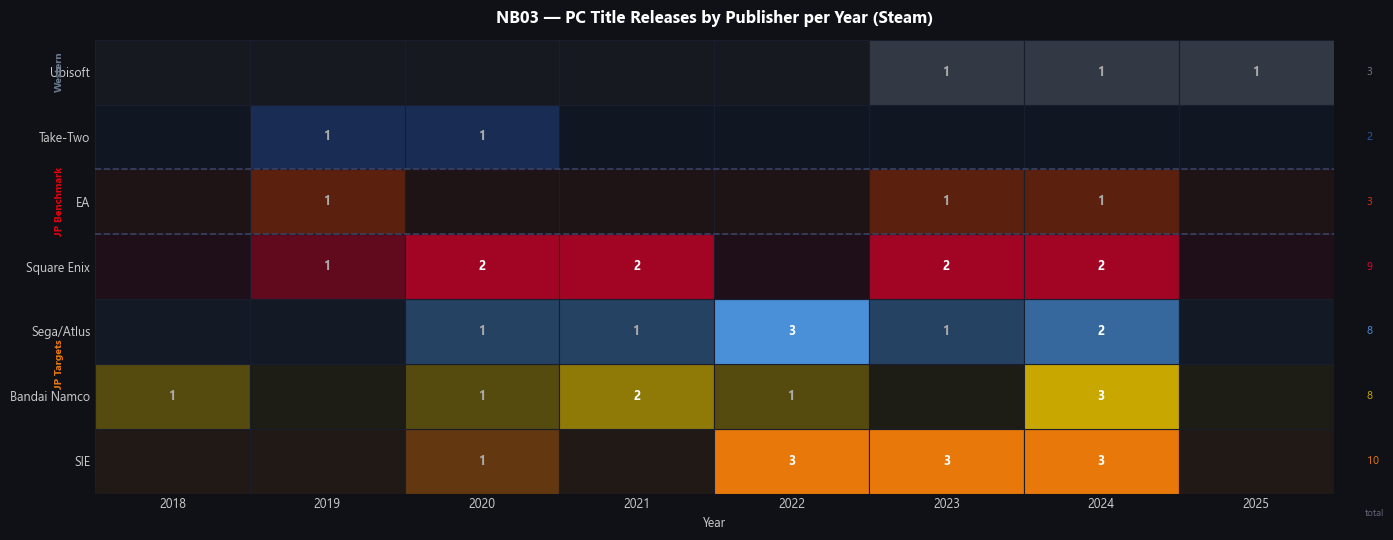

Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB03_platform_chart.png


In [8]:
# ── CELL 8: Visualization — Port Timeline Heatmap ────────────────
# Heatmap: publishers (rows) × years (cols), value = titles released.
# Colour intensity = volume. Annotated with count in each cell.
# JP targets highlighted with left-side group label.

years_to_show = list(range(ANALYSIS_WINDOW[0], ANALYSIS_WINDOW[1] + 1))
pub_order     = [p for p in ALL_GROUPS if p in timeline_pivot.index]
display_order = [DISPLAY_NAMES[p] for p in pub_order]

matrix = np.zeros((len(pub_order), len(years_to_show)))
for i, pub in enumerate(pub_order):
    for j, yr in enumerate(years_to_show):
        if yr in timeline_pivot.columns:
            matrix[i, j] = timeline_pivot.loc[pub, yr]

fig, ax = plt.subplots(figsize=(14, 5.5))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#0F1117')

vmax = max(matrix.max(), 1)
for i, pub in enumerate(pub_order):
    base_color = PUBLISHER_COLORS.get(pub, '#555555')
    r_c = int(base_color[1:3], 16) / 255
    g_c = int(base_color[3:5], 16) / 255
    b_c = int(base_color[5:7], 16) / 255
    for j, yr in enumerate(years_to_show):
        val   = matrix[i, j]
        alpha = 0.08 + 0.92 * (val / vmax) if vmax > 0 else 0.08
        rect  = plt.Rectangle([j - 0.5, i - 0.5], 1, 1,
                               facecolor=(r_c, g_c, b_c, alpha),
                               edgecolor='#1A1D2E', linewidth=0.8)
        ax.add_patch(rect)
        if val > 0:
            ax.text(j, i, str(int(val)),
                    ha='center', va='center',
                    fontsize=9, fontweight='bold',
                    color='white' if alpha > 0.4 else '#AAAAAA')

sep_after = len(JP_TARGETS) - 0.5
ax.axhline(sep_after, color='#3D4060', linewidth=1.2, linestyle='--')
ax.axhline(sep_after + len(JP_BENCHMARK), color='#3D4060',
           linewidth=1.2, linestyle='--')

group_labels = [
    (len(JP_TARGETS) / 2 - 0.5,                          'JP Targets',   '#E8780A'),
    (len(JP_TARGETS) + 0.0,                               'JP Benchmark', '#E4000F'),
    (len(JP_TARGETS) + len(JP_BENCHMARK) + len(WESTERN) / 2 - 0.5, 'Western', '#6B7A8D'),
]
for y_pos, label, color in group_labels:
    ax.text(-0.7, y_pos, label,
            ha='right', va='center', fontsize=7.5,
            color=color, fontweight='bold', rotation=90)

ax.set_xlim(-0.5, len(years_to_show) - 0.5)
ax.set_ylim(-0.5, len(pub_order) - 0.5)
ax.set_xticks(range(len(years_to_show)))
ax.set_xticklabels(years_to_show, fontsize=9, color='#CCCCCC')
ax.set_yticks(range(len(pub_order)))
ax.set_yticklabels(display_order, fontsize=9, color='#CCCCCC')
ax.tick_params(length=0)
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.set_title('NB03 — PC Title Releases by Publisher per Year (Steam)',
             color='white', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Year', color='#CCCCCC', fontsize=9)

for i, pub in enumerate(pub_order):
    total = int(matrix[i].sum())
    ax.text(len(years_to_show) - 0.3, i, f' {total}',
            ha='left', va='center', fontsize=8,
            color=PUBLISHER_COLORS.get(pub, '#AAAAAA'))
ax.text(len(years_to_show) - 0.3, -0.8, 'total',
        ha='left', va='center', fontsize=7, color='#666677')

plt.tight_layout()
out_path = PROCESSED / 'NB03_platform_chart.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'Saved: {out_path}')


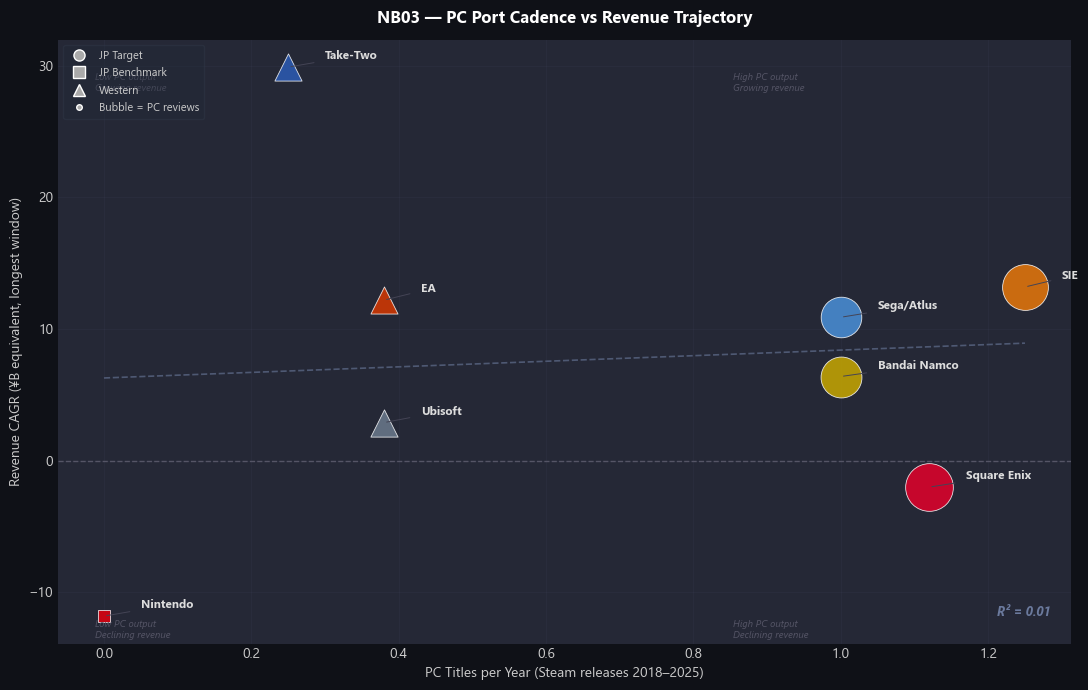

Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB03_cadence_revenue_chart.png


In [9]:
# ── CELL 9: Visualization — Cadence vs Revenue Scatter ───────────
# X axis: titles_per_year (PC port volume)
# Y axis: revenue_cagr (revenue trajectory)
# Bubble size: total_reviews (PC audience reach proxy)
# Colour: publisher brand colour
# Shape: JP target (circle) / JP benchmark (square) / Western (triangle)
#
# The central thesis chart. R² from Cell 7 annotated directly.

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0F1117')
ax.set_facecolor('#252836')

max_reviews = plot_df['total_reviews'].max()
min_reviews = plot_df['total_reviews'].min()

def bubble_size(reviews):
    if max_reviews == min_reviews:
        return 400
    return 80 + 1100 * (reviews - min_reviews) / (max_reviews - min_reviews)

for pub, row in plot_df.iterrows():
    color  = PUBLISHER_COLORS.get(pub, '#555555')
    size   = bubble_size(row['total_reviews'])
    marker = 'o' if pub in JP_TARGETS else ('s' if pub in JP_BENCHMARK else '^')
    ax.scatter(
        row['titles_per_year'], row['revenue_cagr'],
        s=size, color=color, alpha=0.85,
        marker=marker, edgecolors='white', linewidths=0.6, zorder=3
    )
    ax.annotate(
        DISPLAY_NAMES.get(pub, pub),
        xy=(row['titles_per_year'], row['revenue_cagr']),
        xytext=(row['titles_per_year'] + 0.05, row['revenue_cagr'] + 0.6),
        fontsize=8.5, color='#DDDDDD', fontweight='bold',
        arrowprops=dict(arrowstyle='-', color='#444455', lw=0.7,
                        shrinkA=6, shrinkB=2),
    )

ax.axhline(0, color='#555566', linewidth=1.0, linestyle='--', zorder=2)

# OLS trend line + R² annotation (computed in Cell 7)
x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_line, p_fit(x_line), color='#6B7A9D', linewidth=1.2,
        linestyle='--', alpha=0.6, zorder=1)
ax.text(0.98, 0.04, f'R² = {r2:.2f}',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color='#6B7A9D', style='italic', fontweight='bold')

# Quadrant labels
ylim = ax.get_ylim()
xlim = ax.get_xlim()
ax.text(xlim[0] + 0.05, ylim[1] * 0.92,
        'Low PC output\nGrowing revenue',
        fontsize=7, color='#555566', style='italic', va='top')
ax.text(xlim[1] * 0.65, ylim[1] * 0.92,
        'High PC output\nGrowing revenue',
        fontsize=7, color='#555566', style='italic', va='top')
ax.text(xlim[0] + 0.05, ylim[0] + 0.3,
        'Low PC output\nDeclining revenue',
        fontsize=7, color='#555566', style='italic', va='bottom')
ax.text(xlim[1] * 0.65, ylim[0] + 0.3,
        'High PC output\nDeclining revenue',
        fontsize=7, color='#555566', style='italic', va='bottom')

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#AAAAAA',
           markersize=8, label='JP Target', linestyle='None'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#AAAAAA',
           markersize=8, label='JP Benchmark', linestyle='None'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor='#AAAAAA',
           markersize=8, label='Western', linestyle='None'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#AAAAAA',
           markersize=4, label='Bubble = PC reviews', linestyle='None'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8,
          labelcolor='#CCCCCC', framealpha=0.3)

ax.set_xlabel('PC Titles per Year (Steam releases 2018–2025)',
              color='#CCCCCC', fontsize=10)
ax.set_ylabel('Revenue CAGR (¥B equivalent, longest window)',
              color='#CCCCCC', fontsize=10)
ax.set_title('NB03 — PC Port Cadence vs Revenue Trajectory',
             color='white', fontsize=12, fontweight='bold', pad=12)
ax.grid(alpha=0.12, color='#4A5068')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.tick_params(length=0)

plt.tight_layout()
out_path = PROCESSED / 'NB03_cadence_revenue_chart.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print(f'Saved: {out_path}')


In [10]:
# ── CELL 10: Save Outputs ─────────────────────────────────────────
out_timeline = PROCESSED / 'NB03_port_timeline.csv'
port_timeline_df.to_csv(out_timeline, index=False)
print(f'Saved: {out_timeline}  ({len(port_timeline_df)} rows)')

out_metrics = PROCESSED / 'NB03_publisher_metrics.csv'
metrics_df.to_csv(out_metrics)
print(f'Saved: {out_metrics}')


Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB03_port_timeline.csv  (46 rows)
Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\2. ThePlatformShift_ADeepDive\data\processed\NB03_publisher_metrics.csv


In [11]:
# ── CELL 11: NB03 Observation ────────────────────────────────────
top_cadence  = cadence_df['titles_per_year'].idxmax()
top_reach    = review_agg['total_reviews'].idxmax()
highest_cagr = metrics_df['revenue_cagr'].idxmax()
lowest_cagr  = metrics_df['revenue_cagr'].idxmin()

jp_metrics     = metrics_df.loc[JP_TARGETS].copy()
jp_avg_cadence = jp_metrics['titles_per_year'].mean()
jp_avg_cagr    = jp_metrics['revenue_cagr'].mean()

print(f"""
NB03 Observation
─────────────────────────────────────────────────────
Analysis window  : {ANALYSIS_WINDOW[0]}–{ANALYSIS_WINDOW[1]}
Publishers       : {len(ALL_GROUPS)} ({len(JP_TARGETS)} JP targets, {len(JP_BENCHMARK)} JP benchmark, {len(WESTERN)} Western)
Total titles     : {int(timeline_pivot.sum().sum())} Steam releases tracked

Port cadence
  Highest output : {DISPLAY_NAMES.get(top_cadence, top_cadence)} ({cadence_df.loc[top_cadence,'titles_per_year']:.1f} titles/yr)
  JP avg cadence : {jp_avg_cadence:.1f} titles/yr

PC audience reach
  Most reviews   : {DISPLAY_NAMES.get(top_reach, top_reach)} ({review_agg.loc[top_reach,'total_reviews']:,.0f} total reviews)

Thesis finding (Cell 7)
  Pearson r      : {pearson_r:+.3f}
  OLS R²         : {r2:.2f}
  Interpretation : PC port volume explains {r2*100:.0f}% of revenue variance.
                   Volume is NOT the driver — quality of PC strategy is.

Revenue trajectory
  Highest CAGR   : {DISPLAY_NAMES.get(highest_cagr, highest_cagr)} ({metrics_df.loc[highest_cagr,'revenue_cagr']:+.1f}%)
  Lowest CAGR    : {DISPLAY_NAMES.get(lowest_cagr, lowest_cagr)} ({metrics_df.loc[lowest_cagr,'revenue_cagr']:+.1f}%)
  JP avg CAGR    : {jp_avg_cagr:+.1f}%

Known gaps
  — Nintendo excluded from PC cadence (zero Steam presence)
  — FF7 Rebirth release_pc date in registry may be wrong (2024-01-23
    vs patch file 2025-01-23); gap currently shows 0 — verify
  — oc_score / positive_rate filled by prepare_streamlit_data.py,
    not computed in this notebook
  — NB02_TO_NB01 key mapping: single source of truth in Cell 1

Next: NB04 — Sentiment Analysis
""")



NB03 Observation
─────────────────────────────────────────────────────
Analysis window  : 2018–2025
Publishers       : 8 (4 JP targets, 1 JP benchmark, 3 Western)
Total titles     : 43 Steam releases tracked

Port cadence
  Highest output : SIE (1.2 titles/yr)
  JP avg cadence : 1.1 titles/yr

PC audience reach
  Most reviews   : Square Enix (55,197 total reviews)

Thesis finding (Cell 7)
  Pearson r      : +0.081
  OLS R²         : 0.01
  Interpretation : PC port volume explains 1% of revenue variance.
                   Volume is NOT the driver — quality of PC strategy is.

Revenue trajectory
  Highest CAGR   : Take-Two (+29.9%)
  Lowest CAGR    : Nintendo (-11.8%)
  JP avg CAGR    : +7.1%

Known gaps
  — Nintendo excluded from PC cadence (zero Steam presence)
  — FF7 Rebirth release_pc date in registry may be wrong (2024-01-23
    vs patch file 2025-01-23); gap currently shows 0 — verify
  — oc_score / positive_rate filled by prepare_streamlit_data.py,
    not computed in this note